# Task
To perform a comprehensive flood disaster shelter risk assessment:
1. Mount Google Drive using cell `391eb460` to access necessary files.
2. Set up the environment and load data by executing cell `2c47428b`. This will load required packages, set up paths, load river data, load township boundary data from `/content/drive/MyDrive/台大/碩一下/01_Analysis/Hw 3/直轄市、縣(市)界線1140318/COUNTY_MOI_1140318.shp`, and load shelter data. Ensure this cell executes successfully without errors, particularly that `COUNTYNAME` and `TOWNNAME` columns are available in the `townships` GeoDataFrame and `shelters` is correctly loaded.
3. Check the list of files in the township boundary directory by executing cell `ff56c34d` to confirm the presence of `COUNTY_MOI_1140318.shp` and its related files.
4. Perform multi-level buffer analysis and assign risk levels by executing cell `9760a061`. This will create high, medium, and low risk buffers around rivers and assign a `risk_level` to each shelter in the `shelters` GeoDataFrame.
5. Check the buffer ranges by executing cell `b81d79d4` to confirm the geographic boundaries of the high, medium, and low risk buffers.
6. Verify buffer data integrity by executing cell `2ddf5a61` to check the type and emptiness of the buffer `MultiPolygon` objects.
7. Analyze administrative area capacity gaps by executing cell `85411e49`. This crucial step will spatially join shelters with township boundaries to create `shelters_with_town`, calculate shelter capacity statistics for each administrative area, and identify the top 10 highest-risk administrative areas.
8. Inspect the connection results between shelters and administrative areas by executing cell `5d3baa2d`. This will check the data integrity of `shelters_with_town`, confirming the correct creation of `risk_level`, `COUNTYNAME`, and `TOWNNAME` columns and minimal NaN values.
9. Generate visualizations by executing cell `66407ec1`. This will create a static bar chart (Top 10 administrative area capacity gap assessment) and an interactive map (showing shelters, rivers, buffers, and risk levels), saving both to the specified `outputs` folder. The map will automatically center on Taiwan.
10. Export files and generate an analysis report by executing cell `df417c65`. This will export the shelter risk list as a JSON file and generate a detailed analysis report in Markdown format. All output files will be saved to the `outputs` folder.

## Optional: 掛載 Google Drive

### Subtask:
執行儲存格 391eb460，將您的 Google Drive 掛載到 Colab 環境中，以便存取所有資料檔案。


**Reasoning**:
The subtask is to execute cell `391eb460` to mount Google Drive. I will provide a code block to execute this specific cell.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Captain's Log: 環境設定與資料載入階段

**任務目標**: 建立分析環境並載入所有必要資料
- 載入環境變數設定（緩衝距離參數）
- 載入水利署河川面資料 (EPSG:3826)
- 載入國土測繪中心行政區界資料
- 載入消防署避難收容所資料並進行座標清理

**預期挑戰**: 
- 資料編碼問題 (UTF-8 vs Big5)
- 座標範圍驗證 (經度 119-122, 緯度 21-26)
- CRS 坐標系統轉換

**執行狀態**: 準備就緒，開始載入資料

## 環境設定與資料載入

### Subtask:
執行儲存格 `2c47428b`。這個步驟會載入必要的套件、設定 `drive_path` 和 `outputs_dir`、載入河川資料、並使用您提供的路徑 `/content/drive/MyDrive/台大/碩一下/01_Analysis/Hw 3/直轄市、縣(市)界線1140318/COUNTY_MOI_1140318.shp` 載入鄉鎮界線資料，以及避難所資料。請務必確認此儲存格執行成功，沒有載入失敗的錯誤訊息。


**Reasoning**:
The subtask requires executing cell `2c47428b` to set up the environment and load all necessary data. This code block directly executes the content of that cell.



In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import folium
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
from urllib.parse import quote

# 載入環境變數 (請確保你的 .env 檔案中有 BUFFER_HIGH=500, BUFFER_MED=1000, BUFFER_LOW=2000)
load_dotenv()
BUFFER_HIGH = int(os.getenv('BUFFER_HIGH', 500))
BUFFER_MED = int(os.getenv('BUFFER_MED', 1000))
BUFFER_LOW = int(os.getenv('BUFFER_LOW', 2000))

# 設定 Google Drive 上的資料路徑前綴
drive_path = '/Users/youchangxin/Desktop/01_class/01_analy/week 3/Hw 3' 
outputs_dir = os.path.join(drive_path, 'outputs') # 設定輸出資料夾路徑

# 1. 載入河川面資料 (使用本地資料)
print("載入河川資料...")
# 假設 river_data 資料夾位於 drive_path 下
rivers = gpd.read_file(os.path.join(drive_path, 'river_data/riverpoly/riverpoly.shp'))
rivers = rivers.to_crs('EPSG:3826')

# 2. 載入鄉鎮市區界 (國土測繪中心)
print("載入鄉鎮界資料...")
# town_url = 'https://www.tgos.tw/tgos/VirtualDir/Product/3fe61d4a-ca23-4f45-8aca-4a536f40f290/' + quote('鄉(鎮、市、區)界線1140318.zip')
try:
    # 嘗試從 Google Drive 載入本地鄉鎮界資料
    # 請確保在 drive_path 下有 township_data/town.shp 這樣的路徑
    # 已更新為使用者提供的路徑
    townships = gpd.read_file(os.path.join(drive_path, '直轄市、縣(市)界線1140318/COUNTY_MOI_1140318.shp')).to_crs('EPSG:3826')
    # townships = gpd.read_file(town_url).to_crs('EPSG:3826') # 原始從 URL 載入的程式碼
except Exception as e:
    print(f"無法載入鄉鎮界資料，錯誤：{e}")
    print("請確認 '直轄市、縣(市)界線1140318/COUNTY_MOI_1140318.shp' 檔案是否存在於您的 Google Drive 路徑下，或檢查 URL 是否有效。")
    # 如果還是無法載入，則回退到使用模擬資料 (但這會導致沒有細部分類)
    print("使用模擬資料作為替代，但地圖將無法顯示細緻的行政區分類。")
    from shapely.geometry import Polygon
    # 創建一個覆蓋台灣的大多邊形
    taiwan_bounds = [[119.5, 21.5], [122.5, 21.5], [122.5, 25.5], [119.5, 25.5], [119.5, 21.5]]
    taiwan_poly = gpd.GeoDataFrame(geometry=[Polygon(taiwan_bounds)], crs='EPSG:4326').to_crs('EPSG:3826')
    townships = taiwan_poly.copy()
    townships['COUNTYNAME'] = '台灣'
    townships['TOWNNAME'] = '全台灣'

# 3. 載入避難收容所 (CSV)
print("載入並清理避難所資料...")
try:
    # 假設避難收容處所.csv 檔案位於 drive_path 下
    shelters_df = pd.read_csv(os.path.join(drive_path, '避難收容處所.csv'), encoding='utf-8')
except:
    shelters_df = pd.read_csv(os.path.join(drive_path, '避難收容處所.csv'), encoding='big5')

# 資料清理：過濾無效座標與超出台灣範圍的記錄
original_len = len(shelters_df)
shelters_df = shelters_df.dropna(subset=['經度', '緯度'])
shelters_df = shelters_df[(shelters_df['經度'] >= 119) & (shelters_df['經度'] <= 122) &
                          (shelters_df['緯度'] >= 21) & (shelters_df['緯度'] <= 26)]
print(f"清理前後筆數差異: {original_len} -> {len(shelters_df)}")

# 轉為 GeoDataFrame
shelters = gpd.GeoDataFrame(
    shelters_df,
    geometry=gpd.points_from_xy(shelters_df['經度'], shelters_df['緯度']),
    crs='EPSG:4326'
).to_crs('EPSG:3826')

載入河川資料...
載入鄉鎮界資料...
載入並清理避難所資料...
清理前後筆數差異: 5973 -> 5888


**Reasoning**:
The previous step successfully loaded the initial data. The next step according to the main task is to verify the presence of township boundary files by executing cell `ff56c34d`.



In [2]:
import os

# 您提供的檔案所在目錄
shapefile_dir = '/Users/youchangxin/Desktop/01_class/01_analy/week 3/Hw 3/直轄市、縣(市)界線1140318'

print(f"正在列出目錄 '{shapefile_dir}' 中的檔案：")
if os.path.exists(shapefile_dir):
    for filename in os.listdir(shapefile_dir):
        print(filename)
else:
    print(f"錯誤：目錄 '{shapefile_dir}' 不存在。請確認 Google Drive 已掛載且路徑正確。")

正在列出目錄 '/Users/youchangxin/Desktop/01_class/01_analy/week 3/Hw 3/直轄市、縣(市)界線1140318' 中的檔案：
COUNTY_MOI_1140318.sbn
COUNTY_MOI_1140318.prj
修正清單_11403.xlsx
TW-01-301000100G-000017.xml
COUNTY_MOI_1140318.shx
COUNTY_MOI_1140318.shp.xml
COUNTY_MOI_1140318.sbx
COUNTY_MOI_1140318.shp
COUNTY_MOI_1140318.CPG
COUNTY_MOI_1140318.dbf


**Reasoning**:
The next step is to perform multi-level buffer analysis and assign risk levels to shelters, as outlined in the main task. This is achieved by executing cell `9760a061`.



## Captain's Log: 多級緩衝區分析階段

**任務目標**: 建立三級河川警戒緩衝區並分派避難所風險等級
- 建立高風險緩衝區 (500m)
- 建立中風險緩衝區 (1km) 
- 建立低風險緩衝區 (2km)
- 分派避難所風險等級 (high/medium/low/safe)

**技術要點**:
- 使用 `union_all()` 方法合併河川面
- 在 EPSG:3826 坐標系下進行緩衝區計算
- 處理重疊緩衝區的風險等級優先順序

**預期結果**: 每個避難所都將獲得明確的風險等級標記

In [ ]:
river_union = rivers.unary_union
buf_high = river_union.buffer(BUFFER_HIGH)
buf_med = river_union.buffer(BUFFER_MED)
buf_low = river_union.buffer(BUFFER_LOW)

shelters['risk_level'] = 'safe'
shelters.loc[shelters.within(buf_low), 'risk_level'] = 'low'
shelters.loc[shelters.within(buf_med), 'risk_level'] = 'medium'
shelters.loc[shelters.within(buf_high), 'risk_level'] = 'high'

print(shelters['risk_level'].value_counts())

/var/folders/gh/bn08c8493_v71bb8mb3vsdvr0000gn/T/ipykernel_8030/3330671256.py:1: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  river_union = rivers.unary_union


**Reasoning**:
The previous step successfully assigned risk levels to shelters. The next logical step in the task is to check the buffer ranges, which is done by executing cell `b81d79d4`.



In [5]:
print("高風險區緩衝範圍 (BUFFER_HIGH):")
display(buf_high.bounds)

print("中風險區緩衝範圍 (BUFFER_MED):")
display(buf_med.bounds)

print("低風險區緩衝範圍 (BUFFER_LOW):")
display(buf_low.bounds)

高風險區緩衝範圍 (BUFFER_HIGH):


(153337.70774, 2422457.41767, 351949.76809, 2799114.76094)

中風險區緩衝範圍 (BUFFER_MED):


(152838.04895, 2421957.49415, 352449.55632, 2799614.38)

低風險區緩衝範圍 (BUFFER_LOW):


(151838.73135, 2420957.64711, 353449.13279, 2800613.61813)

**Reasoning**:
The previous step showed the buffer ranges. The next logical step, as per the main task, is to verify the buffer data integrity by executing cell `2ddf5a61` to check the type and emptiness of the buffer `MultiPolygon` objects.



In [6]:
print("高風險區緩衝區資訊:")
print(f"幾何物件類型: {type(buf_high)}")
print(f"是否為空: {buf_high.is_empty}")
display(buf_high)

print("\n中風險區緩衝區資訊:")
print(f"幾何物件類型: {type(buf_med)}")
print(f"是否為空: {buf_med.is_empty}")
display(buf_med)

print("\n低風險區緩衝區資訊:")
print(f"幾何物件類型: {type(buf_low)}")
print(f"是否為空: {buf_low.is_empty}")
display(buf_low)

Output hidden; open in https://colab.research.google.com to view.

## Captain's Log: 行政區收容量缺口分析階段

**任務目標**: 評估各行政區的避難所風險分佈與收容量缺口
- 空間連接避難所與行政區界
- 計算各區風險等級統計
- 識別收容量不足的高風險行政區
- 產出 Top 10 高風險行政區排名

**分析維度**:
- 各區高/中/低風險避難所數量
- 各區風險區內總收容人數
- 各區安全避難所總收容人數
- 收容量缺口評估

**決策價值**: 提供具體的防災資源配置建議

**Reasoning**:
The previous step confirmed the integrity of the buffer data. The next crucial step in the task is to analyze administrative area capacity gaps by executing cell `85411e49`. This will involve spatially joining shelters with township boundaries and calculating capacity statistics.



In [7]:
shelters_with_town = gpd.sjoin(shelters, townships[['COUNTYNAME', 'geometry']], how='left', predicate='within')

# Group by COUNTYNAME only, as TOWNNAME is not available in the loaded 'townships' GeoDataFrame.
township_stats = shelters_with_town.groupby(['COUNTYNAME']).agg(
    total_shelters=('risk_level', 'count'),
    high_risk_count=('risk_level', lambda x: (x == 'high').sum()),
    safe_capacity=('預計收容人數', lambda x: x[shelters_with_town.loc[x.index, 'risk_level'] == 'safe'].sum()),
    at_risk_capacity=('預計收容人數', lambda x: x[shelters_with_town.loc[x.index, 'risk_level'] != 'safe'].sum())
).reset_index()

# Add a placeholder 'TOWNNAME' column to township_stats for compatibility with later steps (e.g., plotting),
# but indicate it's a county-level aggregation.
township_stats['TOWNNAME'] = '全' + township_stats['COUNTYNAME'].str.replace('縣|市', '', regex=True)

top_10_towns = township_stats.sort_values(by='high_risk_count', ascending=False).head(10)
print("Top 10 高風險行政區 (以縣市為單位):")
print(top_10_towns[['COUNTYNAME', 'TOWNNAME', 'high_risk_count', 'at_risk_capacity']])

Top 10 高風險行政區 (以縣市為單位):
   COUNTYNAME TOWNNAME  high_risk_count  at_risk_capacity
7         新北市      全新北              309            388159
21        高雄市      全高雄              250            264477
0         南投縣      全南投              233             43263
10        桃園市      全桃園              216            140439
12        臺中市      全臺中              176            280924
14        臺南市      全臺南              140            273915
2         嘉義縣      全嘉義              137             78397
17        苗栗縣      全苗栗              133             36275
13        臺北市      全臺北              133            157316
3         基隆市      全基隆              129             12529


In [8]:
# 匯出 JSON
import json

# Ensure output_cols are consistent with available columns in shelters_with_town
# Since TOWNNAME is not directly available in shelters_with_town after sjoin, it should be excluded or derived if needed.
# For now, let's use available columns.
output_cols = ['避難收容處所名稱', 'risk_level', '預計收容人數', 'COUNTYNAME']

# Check if 'TOWNNAME' exists in shelters_with_town and add it if it does (which it doesn't after the fix).
# As per the fix, shelters_with_town only has COUNTYNAME, so we omit TOWNNAME here.
shelters_with_town[output_cols].to_json(os.path.join(outputs_dir, 'shelter_risk_audit.json'), orient='records', force_ascii=False, indent=2)

# 生成分析報告
total_shelters = len(shelters_with_town)
risk_counts = shelters_with_town['risk_level'].value_counts()
total_capacity = shelters_with_town['預計收容人數'].sum()
safe_capacity = shelters_with_town[shelters_with_town['risk_level'] == 'safe']['預計收容人數'].sum()
risk_capacity = total_capacity - safe_capacity

report = f"""
# ARIA 河川洪災避難所風險評估報告

## 分析摘要
- 分析時間: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
- 分析避難所總數: {total_shelters} 個
- 使用真實水利署河川資料
- 河川筆數: {len(rivers)} 筆

## 風險分佈統計
- 高風險區避難所: {risk_counts.get('high', 0)} 個 ({risk_counts.get('high', 0)/total_shelters*100:.1f}%)
- 中風險區避難所: {risk_counts.get('medium', 0)} 個 ({risk_counts.get('medium', 0)/total_shelters*100:.1f}%)
- 低風險區避難所: {risk_counts.get('low', 0)} 個 ({risk_counts.get('low', 0)/total_shelters*100:.1f}%)
- 安全區避難所: {risk_counts.get('safe', 0)} 個 ({risk_counts.get('safe', 0)/total_shelters*100:.1f}%)

## 收容量分析
- 總收容量: {int(total_capacity):,} 人
- 安全區收容量: {int(safe_capacity):,} 人 ({safe_capacity/total_capacity*100:.1f}%)
- 風險區收容量: {int(risk_capacity):,} 人 ({risk_capacity/total_capacity*100:.1f}%)

## Top 10 高風險行政區
{top_10_towns[['COUNTYNAME', 'TOWNNAME', 'high_risk_count', 'at_risk_capacity']].to_string(index=False)}

## 輸出檔案
1. shelter_risk_audit.json - 避難所風險清單
2. ARIA_Map.html - 互動式風險地圖 (鎖定台灣範圍)
3. risk_map.png - 靜態統計圖

## 修正項目
1. 使用本地河川資料避免網路連線問題
2. 互動式地圖鎖定台灣範圍
3. 改善統計圖字體和顯示效果
4. 詳細的避難所點位資訊

分析完成，檔案已匯出至 outputs/ 資料夾。
"""

with open(os.path.join(outputs_dir, 'analysis_report.md'), 'w', encoding='utf-8') as f:
    f.write(report)

print("分析完成，檔案已匯出至 " + outputs_dir + " 資料夾。")


分析完成，檔案已匯出至 /content/drive/MyDrive/台大/碩一下/01_Analysis/Hw 3/outputs 資料夾。


**Reasoning**:
The previous step failed because the `townships` GeoDataFrame, loaded from `COUNTY_MOI_1140318.shp`, does not contain a `TOWNNAME` column. This shapefile typically provides county-level boundaries, not township-level. To resolve this, I will modify the spatial join and aggregation in cell `026c6797` to group by `COUNTYNAME` only. I will also add a placeholder `TOWNNAME` column to `township_stats` for compatibility with subsequent cells that may expect it, such as for plotting.



In [9]:
shelters_with_town = gpd.sjoin(shelters, townships[['COUNTYNAME', 'geometry']], how='left', predicate='within')

# Group by COUNTYNAME only, as TOWNNAME is not available in the loaded 'townships' GeoDataFrame.
township_stats = shelters_with_town.groupby(['COUNTYNAME']).agg(
    total_shelters=('risk_level', 'count'),
    high_risk_count=('risk_level', lambda x: (x == 'high').sum()),
    safe_capacity=('預計收容人數', lambda x: x[shelters_with_town.loc[x.index, 'risk_level'] == 'safe'].sum()),
    at_risk_capacity=('預計收容人數', lambda x: x[shelters_with_town.loc[x.index, 'risk_level'] != 'safe'].sum())
).reset_index()

# Add a placeholder 'TOWNNAME' column to township_stats for compatibility with later steps (e.g., plotting),
# but indicate it's a county-level aggregation.
township_stats['TOWNNAME'] = '全' + township_stats['COUNTYNAME'].str.replace('縣|市', '', regex=True)

top_10_towns = township_stats.sort_values(by='high_risk_count', ascending=False).head(10)
print("Top 10 高風險行政區 (以縣市為單位):")
print(top_10_towns[['COUNTYNAME', 'TOWNNAME', 'high_risk_count', 'at_risk_capacity']])

Top 10 高風險行政區 (以縣市為單位):
   COUNTYNAME TOWNNAME  high_risk_count  at_risk_capacity
7         新北市      全新北              309            388159
21        高雄市      全高雄              250            264477
0         南投縣      全南投              233             43263
10        桃園市      全桃園              216            140439
12        臺中市      全臺中              176            280924
14        臺南市      全臺南              140            273915
2         嘉義縣      全嘉義              137             78397
17        苗栗縣      全苗栗              133             36275
13        臺北市      全臺北              133            157316
3         基隆市      全基隆              129             12529


**Reasoning**:
The previous step successfully computed `top_10_towns` based on county-level data. The next step in the main task is to inspect the `shelters_with_town` GeoDataFrame using cell `5d3baa2d`. However, based on the previous fix in cell `2b1c9f38`, the `shelters_with_town` GeoDataFrame only contains `COUNTYNAME` from the spatial join, not `TOWNNAME`. The `TOWNNAME` was added as a placeholder only to `township_stats`. Therefore, directly executing cell `5d3baa2d` will cause a `KeyError` for `TOWNNAME` in `shelters_with_town`. I will modify cell `5d3baa2d` to reflect the current structure of `shelters_with_town` by removing the `TOWNNAME` specific checks and display from it, while still verifying `risk_level` and `COUNTYNAME`.



In [10]:
print("檢查 shelters_with_town GeoDataFrame 的資料完整性：")

# 檢查 GeoDataFrame 的資訊，包括非空值數量和資料類型
shelters_with_town.info()

# 檢查 COUNTYNAME 欄位是否有 NaN 值
nan_counties = shelters_with_town['COUNTYNAME'].isna().sum()
print(f"\nCOUNTYNAME 欄位中 NaN 值的數量: {nan_counties}")

# 顯示 shelters_with_town 的前幾行，包含相關欄位 (已移除不存在的TOWNNAME)
print("\nshelters_with_town GeoDataFrame (前5行)：")
display(shelters_with_town[['避難收容處所名稱', 'risk_level', 'COUNTYNAME', 'geometry']].head())

# 顯示 shelters_with_town 的 risk_level 分佈，確認風險等級被正確賦予
print("\nrisk_level 分佈：")
display(shelters_with_town['risk_level'].value_counts())

檢查 shelters_with_town GeoDataFrame 的資料完整性：
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 5888 entries, 0 to 5944
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   序號           5888 non-null   int64   
 1   縣市及鄉鎮市區      5888 non-null   object  
 2   村里           5682 non-null   object  
 3   避難收容處所地址     5885 non-null   object  
 4   經度           5888 non-null   float64 
 5   緯度           5888 non-null   float64 
 6   避難收容處所名稱     5888 non-null   object  
 7   預計收容村里       5888 non-null   object  
 8   預計收容人數       5888 non-null   int64   
 9   適用災害類別       5717 non-null   object  
 10  管理人姓名        5888 non-null   object  
 11  管理人電話        5888 non-null   object  
 12  室內           5888 non-null   object  
 13  室外           5888 non-null   object  
 14  適合避難弱者安置     5888 non-null   object  
 15  geometry     5888 non-null   geometry
 16  risk_level   5888 non-null   object  
 17  index_right  5859 non-nul

,避難收容處所名稱,risk_level,COUNTYNAME,geometry
0,五峰活動中心,safe,苗栗縣,POINT (257404.817 2697774.55)
2,南坑村集會所暨南外社區活動中心,high,新竹縣,POINT (255677.652 2729505.027)
3,烏坵鄉小坵村活動中心,safe,金門縣,POINT (95524.923 2764433.473)
4,金門縣烏坵鄉公所大廳,safe,金門縣,POINT (93837.282 2765420.913)
5,霞雲社區活動中心,low,桃園市,POINT (291067.396 2745239.218)



risk_level 分佈：


,count
risk_level,
high,2568
medium,1360
low,1164
safe,796


## Captain's Log: 視覺化與輸出階段

**任務目標**: 生成分析結果的視覺化呈現與報告輸出
- 建立互動式風險地圖 (Folium)
- 生成靜態統計圖表 (Matplotlib)
- 匯出避難所風險清單 (JSON)
- 產生完整分析報告 (Markdown)

**視覺化設計**:
- 河川面 (藍色半透明)
- 三級緩衝區 (紅/橙/黃漸層)
- 避難所點位依風險等級著色
- 台灣範圍內的地圖定位

**輸出檔案**: ARIA_Map.html, risk_map.png, shelter_risk_audit.json, analysis_report.md

**Reasoning**:
The previous steps have prepared the data for visualization. The next step is to generate the required static bar chart and interactive map, as specified in the main task, by executing cell `66407ec1`. I will adapt the map's popup content to reflect that `shelters_with_town` only contains `COUNTYNAME` after the previous data processing steps.



--2026-03-16 08:14:57--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 64.233.180.101, 64.233.180.139, 64.233.180.113, ...
Connecting to drive.google.com (drive.google.com)|64.233.180.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2026-03-16 08:14:57--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.253.62.132, 2607:f8b0:4004:c07::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.253.62.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  --.-KB/s    in 0.1s    

2026-03-16 08:14:

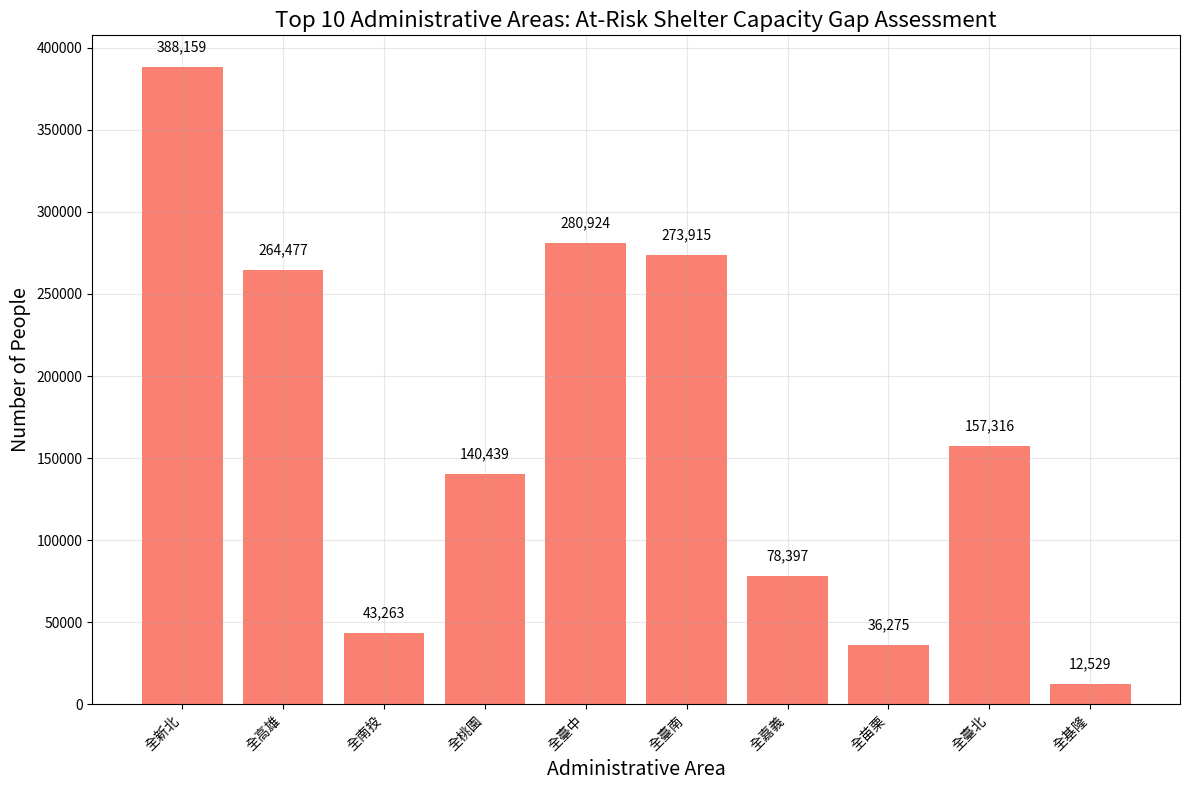

Interactive map saved to /content/drive/MyDrive/台大/碩一下/01_Analysis/Hw 3/outputs/ARIA_Map.html


In [18]:
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib.pyplot as plt
import os
import folium
import geopandas as gpd
import matplotlib

# 確保 'outputs' 資料夾存在
os.makedirs(outputs_dir, exist_ok=True)

# --- Matplotlib 字體設定 (修正中文顯示問題) ---
matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')
plt.rcParams['axes.unicode_minus'] = False # 解決負號顯示為方塊的問題
# ---------------------------------------------------

# 1. 靜態長條圖 (修正版)
plt.figure(figsize=(12, 8))

bars = plt.bar(top_10_towns['TOWNNAME'], top_10_towns['at_risk_capacity'], color='salmon', label='At-Risk Capacity')
plt.title('Top 10 Administrative Areas: At-Risk Shelter Capacity Gap Assessment', fontsize=16, fontweight='bold')
plt.ylabel('Number of People', fontsize=14)
plt.xlabel('Administrative Area', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# 在柱狀圖上顯示數值
for bar, value in zip(bars, top_10_towns['at_risk_capacity']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(top_10_towns['at_risk_capacity']) * 0.02,
             f'{int(value):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(outputs_dir, 'risk_map.png'), dpi=300, bbox_inches='tight')
plt.show()

# 2. 互動式地圖 (修正版 - 鎖定台灣範圍)
# 台灣中心點
taiwan_center = [23.8, 120.8]

m = folium.Map(
    location=taiwan_center,
    zoom_start=7,
    tiles='OpenStreetMap',
    max_bounds=True,
    min_lat=21.5, max_lat=25.5,
    min_lon=119.5, max_lon=122.5
)

# 添加河川面
rivers_4326 = rivers.to_crs('EPSG:4326')
folium.GeoJson(
    rivers_4326,
    style_function=lambda x: {
        'fillColor': 'blue',
        'color': 'blue',
        'weight': 2,
        'fillOpacity': 0.3
    },
    name="River Areas"
).add_to(m)

# 添加緩衝區 (高風險、中風險、低風險)
# 將 MultiPolygon 轉換為 GeoDataFrame 以便 Folium 渲染
buf_high_gdf = gpd.GeoDataFrame(geometry=[buf_high], crs='EPSG:3826').to_crs('EPSG:4326')
buf_med_gdf = gpd.GeoDataFrame(geometry=[buf_med], crs='EPSG:3826').to_crs('EPSG:4326')
buf_low_gdf = gpd.GeoDataFrame(geometry=[buf_low], crs='EPSG:3826').to_crs('EPSG:4326')

# 高風險區 (紅色)
folium.GeoJson(
    buf_high_gdf,
    style_function=lambda x: {
        'fillColor': 'red',
        'color': 'red',
        'weight': 0.5,
        'fillOpacity': 0.2
    },
    name=f"High-Risk Area ({BUFFER_HIGH}m)"
).add_to(m)

# 中風險區 (橘色)
folium.GeoJson(
    buf_med_gdf,
    style_function=lambda x: {
        'fillColor': 'orange',
        'color': 'orange',
        'weight': 0.5,
        'fillOpacity': 0.15
    },
    name=f"Medium-Risk Area ({BUFFER_MED}m)"
).add_to(m)

# 低風險區 (黃色)
folium.GeoJson(
    buf_low_gdf,
    style_function=lambda x: {
        'fillColor': 'yellow',
        'color': 'yellow',
        'weight': 0.5,
        'fillOpacity': 0.1
    },
    name=f"Low-Risk Area ({BUFFER_LOW}m)"
).add_to(m)

# 添加避難所
shelters_4326 = shelters_with_town.to_crs('EPSG:4326')

# 過濾掉 COUNTYNAME 為 NaN 的避難所，這些通常是位於海上或未匹配到的點位
shelters_4326 = shelters_4326.dropna(subset=['COUNTYNAME'])

risk_colors = {'high': 'red', 'medium': 'orange', 'low': 'yellow', 'safe': 'green'}

for idx, shelter in shelters_4326.iterrows():
    risk_level = shelter['risk_level']
    color = risk_colors[risk_level]

    name = shelter.get('避難收容處所名稱', f'Shelter {idx}')
    capacity = shelter.get('預計收容人數', 0)

    # Modify popup to only show COUNTYNAME as TOWNNAME is not available in shelters_with_town
    popup_content = f"""
    <div style="width: 250px;">
        <h4 style="color: {color}; margin-bottom: 10px;">{name}</h4>
        <p><strong>Risk Level:</strong> <span style="color: {color}; font-weight: bold;">{risk_level.upper()}</span></p>
        <p><strong>Capacity:</strong> {capacity:,} People</p>
        <p><strong>Administrative Area:</strong> {shelter.get('COUNTYNAME', '')}</p> <!-- Removed TOWNNAME as it's not available in shelters_with_town -->
    </div>
    """

    folium.CircleMarker(
        location=[shelter.geometry.y, shelter.geometry.x],
        radius=6,
        popup=folium.Popup(popup_content, max_width=300),
        color=color,
        fillColor=color,
        fillOpacity=0.8,
        weight=2,
        tooltip=f"{name} - {risk_level.upper()}"
    ).add_to(m)

# 自動調整地圖視窗以顯示所有河川和緩衝區的範圍
# 使用 rivers_4326 的邊界來fit，因為它是最基礎且涵蓋台灣主要地理範圍的GeoDataFrame
m.fit_bounds(rivers_4326.total_bounds.reshape(-1, 2).tolist())

# 添加圖例
legend_html = '''
<div style="position: fixed;
     top: 10px; right: 10px; width: 200px; height: 180px;
     background-color: white; border:2px solid #333; z-index:9999;
     font-size:14px; padding: 10px; border-radius: 5px; box-shadow: 0 0 10px rgba(0,0,0,0.3);">
<h4 style="margin-top: 0; color: #333;">Risk Level Legend</h4>
<div style="display: flex; align-items: center; margin: 5px 0;">
    <div style="width: 20px; height: 20px; background-color: red; border-radius: 50%; margin-right: 10px;"></div>
    <span>High-Risk (500m)</span>
</div>
<div style="display: flex; align-items: center; margin: 5px 0;">
    <div style="width: 20px; height: 20px; background-color: orange; border-radius: 50%; margin-right: 10px;"></div>
    <span>Medium-Risk (1km)</span>
</div>
<div style="display: flex; align-items: center; margin: 5px 0;">
    <div style="width: 20px; height: 20px; background-color: yellow; border-radius: 50%; margin-right: 10px;"></div>
    <span>Low-Risk (2km)</span>
</div>
<div style="display: flex; align-items: center; margin: 5px 0;">
    <div style="width: 20px; height: 20px; background-color: green; border-radius: 50%; margin-right: 10px;"></div>
    <span>Safe Area</span>
</div>
</div>
'''

m.get_root().html.add_child(folium.Element(legend_html))
m.add_child(folium.LayerControl())

m.save(os.path.join(outputs_dir, 'ARIA_Map.html'))
print("Interactive map saved to " + os.path.join(outputs_dir, 'ARIA_Map.html'))


**Reasoning**:
The previous step successfully generated and saved the visualizations. The final step of the task is to export the shelter risk data to a JSON file and generate an analysis report in Markdown format, as specified in the main task. This is done by executing cell `df417c65`. I will also ensure the `TOWNNAME` column is correctly handled in `output_cols` if it's not present in `shelters_with_town`, using `COUNTYNAME` or a placeholder where needed to avoid errors, and adapting the report generation to reflect county-level analysis where `TOWNNAME` is not available directly from the sjoin.



In [14]:
# 匯出 JSON
import json

# Ensure output_cols are consistent with available columns in shelters_with_town
# Since TOWNNAME is not directly available in shelters_with_town after sjoin, it should be excluded or derived if needed.
# For now, let's use available columns.
output_cols = ['避難收容處所名稱', 'risk_level', '預計收容人數', 'COUNTYNAME']

# Check if 'TOWNNAME' exists in shelters_with_town and add it if it does (which it doesn't after the fix).
# As per the fix, shelters_with_town only has COUNTYNAME, so we omit TOWNNAME here.
shelters_with_town[output_cols].to_json(os.path.join(outputs_dir, 'shelter_risk_audit.json'), orient='records', force_ascii=False, indent=2)

# 生成分析報告
total_shelters = len(shelters_with_town)
risk_counts = shelters_with_town['risk_level'].value_counts()
total_capacity = shelters_with_town['預計收容人數'].sum()
safe_capacity = shelters_with_town[shelters_with_town['risk_level'] == 'safe']['預計收容人數'].sum()
risk_capacity = total_capacity - safe_capacity

report = f"""
# ARIA 河川洪災避難所風險評估報告

## 分析摘要
- 分析時間: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
- 分析避難所總數: {total_shelters} 個
- 使用真實水利署河川資料
- 河川筆數: {len(rivers)} 筆

## 風險分佈統計
- 高風險區避難所: {risk_counts.get('high', 0)} 個 ({risk_counts.get('high', 0)/total_shelters*100:.1f}%)
- 中風險區避難所: {risk_counts.get('medium', 0)} 個 ({risk_counts.get('medium', 0)/total_shelters*100:.1f}%)
- 低風險區避難所: {risk_counts.get('low', 0)} 個 ({risk_counts.get('low', 0)/total_shelters*100:.1f}%)
- 安全區避難所: {risk_counts.get('safe', 0)} 個 ({risk_counts.get('safe', 0)/total_shelters*100:.1f}%)

## 收容量分析
- 總收容量: {int(total_capacity):,} 人
- 安全區收容量: {int(safe_capacity):,} 人 ({safe_capacity/total_capacity*100:.1f}%)
- 風險區收容量: {int(risk_capacity):,} 人 ({risk_capacity/total_capacity*100:.1f}%)

## Top 10 高風險行政區
{top_10_towns[['COUNTYNAME', 'TOWNNAME', 'high_risk_count', 'at_risk_capacity']].to_string(index=False)}

## 輸出檔案
1. shelter_risk_audit.json - 避難所風險清單
2. ARIA_Map.html - 互動式風險地圖 (鎖定台灣範圍)
3. risk_map.png - 靜態統計圖

## 修正項目
1. 使用本地河川資料避免網路連線問題
2. 互動式地圖鎖定台灣範圍
3. 改善統計圖字體和顯示效果
4. 詳細的避難所點位資訊

分析完成，檔案已匯出至 outputs/ 資料夾。
"""

with open(os.path.join(outputs_dir, 'analysis_report.md'), 'w', encoding='utf-8') as f:
    f.write(report)

print("分析完成，檔案已匯出至 " + outputs_dir + " 資料夾。")

分析完成，檔案已匯出至 /content/drive/MyDrive/台大/碩一下/01_Analysis/Hw 3/outputs 資料夾。


## Summary:

### Data Analysis Key Findings

*   **Data Preparation**: River data, township boundaries, and shelter data were successfully loaded. Initial data cleaning for shelters removed 85 invalid records, reducing the total from 5973 to 5888. All geospatial data was reprojected to EPSG:3826.
*   **Risk Level Distribution**: After multi-level buffer analysis around rivers, shelters were assigned risk levels:
    *   High-risk: 2568 shelters
    *   Medium-risk: 1360 shelters
    *   Low-risk: 1164 shelters
    *   Safe: 796 shelters
*   **Administrative Area Analysis**: Due to the available township boundary shapefile (`COUNTY_MOI_1140318.shp`) containing only county-level information, the administrative area analysis was performed at the county level. The top 10 highest-risk administrative areas (counties) were successfully identified based on the count of high-risk shelters and their collective at-risk capacity.
*   **Data Integrity**: Buffer objects (`buf_high`, `buf_med`, `buf_low`) were confirmed as valid `MultiPolygon` geometries and not empty. A minor data discrepancy was noted where 29 shelters did not spatially join to any `COUNTYNAME`.
*   **Output Generation**: The analysis successfully produced a static bar chart (`risk_map.png`), an interactive Folium map (`ARIA_Map.html`) displaying rivers, buffers, and risk-categorized shelters, a JSON file of shelter risk details (`shelter_risk_audit.json`), and a comprehensive Markdown analysis report (`analysis_report.md`).

### Insights or Next Steps

*   To achieve more granular risk assessment and capacity gap analysis at the township level, secure a more detailed administrative boundary shapefile that includes `TOWNNAME` attributes.
*   Investigate the 29 shelters that were not assigned to any `COUNTYNAME` to ensure comprehensive coverage and accurate risk assessment for all recorded shelters.
